This project aims to develop a machine learning system that recommends the most suitable crop to grow and predicts crop yield based on environmental factors, including weather, rainfall, and climate.

#### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import make_scorer


#### Load datasets

In [2]:
df_soil = pd.read_csv('../data/texas.csv')
df_weather = pd.read_csv('../data/texas_weather_2015_2025.csv')
# df_weather_2025 = pd.read_csv('../data/texas_weather_2025.csv')

In [3]:
# See how the data look like
display(df_soil.head())
display(df_weather.head())

,areasymbol,areaname,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,...,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r
0,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,...,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0
1,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,...,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0
2,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,...,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0
3,TX129,"Donley County, Texas",AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,...,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN
4,TX129,"Donley County, Texas",AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,...,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN


,fips_code,prcp_1,prcp_2,prcp_3,prcp_4,prcp_5,prcp_6,prcp_7,prcp_8,prcp_9,...,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12
0,48001,2.900933,2.964329,3.390561,5.274802,5.482412,3.368956,2.154338,2.213802,2.021631,...,9.778649,12.752341,17.891575,21.907337,23.292819,23.144735,19.783293,13.743153,8.519413,5.796549
1,48003,0.618085,0.249359,0.634158,1.418229,1.921028,2.696040,1.638462,2.639070,2.541667,...,5.899730,9.574432,15.242857,19.786648,21.337168,20.795148,17.274184,11.027731,4.795467,1.361318
2,48005,5.320645,3.733105,4.570246,6.129650,7.832726,4.051328,3.969763,4.530125,3.920284,...,10.375305,13.729855,18.534270,22.242754,23.302825,23.010253,20.027536,14.020337,9.096930,6.289610
3,48007,2.281019,0.937309,2.306885,2.215823,4.492989,4.979784,2.275115,2.194407,4.977037,...,15.333683,18.327041,22.442424,25.037123,25.531995,25.269433,23.523677,18.877358,14.045899,10.673762
4,48009,1.350183,1.603846,2.189388,2.864894,4.556282,3.304078,1.509524,2.039051,3.147477,...,7.225806,11.340000,15.262857,20.372414,22.993443,21.267742,17.873333,12.383871,7.016667,-0.370968


#### Merge datasets

In [4]:
# Tweak fips code so that they can be merged
df_soil['fips_code'] = df_soil['areasymbol'].str.replace("TX", "")
df_weather['fips_code'] = df_weather['fips_code'].astype(str).replace(r'^\d{2}', "", regex=True)

# See the change
print(df_soil['fips_code'].head())
print(df_weather['fips_code'].head())

0    129
1    129
2    129
3    129
4    129
Name: fips_code, dtype: str
0    001
1    003
2    005
3    007
4    009
Name: fips_code, dtype: str


In [5]:
# Count how many different unique code in the data
print(df_soil['fips_code'].nunique())
print(df_weather['fips_code'].nunique())

# What are in weather not soil
in_weather_not_soil = set(df_weather['fips_code'].unique()) - set(df_soil['fips_code'].unique())
print(f"In weather but not soil: {len(in_weather_not_soil)}")
print(sorted(in_weather_not_soil))

# What are in soil not weather
in_soil_not_weather = set(df_soil['fips_code'].unique()) - set(df_weather['fips_code'].unique())
print(f"In soil but not weather: {len(in_soil_not_weather)}")
print(sorted(in_soil_not_weather))

232
252
In weather but not soil: 49
['007', '015', '031', '043', '049', '053', '063', '067', '091', '103', '109', '119', '127', '135', '137', '141', '159', '183', '209', '221', '223', '229', '241', '245', '257', '261', '273', '277', '315', '333', '343', '351', '361', '373', '379', '383', '385', '397', '403', '405', '407', '409', '425', '449', '459', '461', '473', '495', '507']
In soil but not weather: 29
['393', '600', '601', '602', '603', '604', '605', '606', '607', '608', '609', '610', '611', '612', '613', '614', '615', '616', '617', '618', '619', '620', '621', '622', '623', '624', '625', '626', '627']


In [6]:
not_in_weather = ['393', '600', '601', '602', '603', '604', '605', '606', '607', '608', '609', '610', '611', '612', '613', '614', '615', '616', '617', '618', '619', '620', '621', '622', '623', '624', '625', '626', '627']
place = df_soil[df_soil['fips_code'].isin(not_in_weather)][['areasymbol', 'areaname']]
print(place.groupby('areasymbol')['areaname'].unique())

areasymbol
TX393                              [Roberts County, Texas]
TX600                  [Austin and Waller Counties, Texas]
TX601                  [Blanco and Burnet Counties, Texas]
TX602                    [Brown and Mills Counties, Texas]
TX603    [Camp, Franklin, Morris, and Titus Counties, T...
TX604                     [Comal and Hays Counties, Texas]
TX605                  [Dimmit and Zavala Counties, Texas]
TX606                    [Ector and Crane Counties, Texas]
TX607                   [Edwards and Real Counties, Texas]
TX608                   [Upshur and Gregg Counties, Texas]
TX609                 [Hood and Somervell Counties, Texas]
TX610                  [Hopkins and Rains Counties, Texas]
TX611                  [Jasper and Newton Counties, Texas]
TX612               [Kaufman and Rockwall Counties, Texas]
TX613                 [Kenedy and Kleberg Counties, Texas]
TX614                    [Lamar and Delta Counties, Texas]
TX615                 [Loving and Winkler Cou

* TX393                              [Roberts County, Texas] 393
* TX600                  [Austin and Waller Counties, Texas] 015, 473
* TX601                  [Blanco and Burnet Counties, Texas] 031, 053
* TX602                    [Brown and Mills Counties, Texas] 049, 333
* TX603    [Camp, Franklin, Morris, and Titus Counties, T... 063, 159, 343, 449
* TX604                     [Comal and Hays Counties, Texas] 091, 209
* TX605                  [Dimmit and Zavala Counties, Texas] 127, 507
* TX606                    [Ector and Crane Counties, Texas] 135, 103
* TX607                   [Edwards and Real Counties, Texas] 137, 385
* TX608                   [Upshur and Gregg Counties, Texas] 459, 183
* TX609                 [Hood and Somervell Counties, Texas] 221, 425
* TX610                  [Hopkins and Rains Counties, Texas] 223, 379
* TX611                  [Jasper and Newton Counties, Texas] 241, 351
* TX612               [Kaufman and Rockwall Counties, Texas] 257, 397
* TX613                 [Kenedy and Kleberg Counties, Texas] 261, 273
* TX614                    [Lamar and Delta Counties, Texas] 277, 119
* TX615                 [Loving and Winkler Counties, Texas] 301, 495
* TX616                    [Marion and Cass Counties, Texas] 315, 067
* TX617               [Polk and San Jacinto Counties, Texas] 373, 407
* TX618                   [Reagan and Upton Counties, Texas] 383, 461
* TX619           [San Augustine and Sabine Counties, Texas] 405, 403
* TX620           [San Patricio and Aransas Counties, Texas] 409, 007
* TX621                      [Big Bend National Park, Texas] 043
* TX622                 [Brewster County, Texas (Main Part)] 043
* TX623               [Jefferson and Orange Counties, Texas] 245, 361
* TX624                  [El Paso County, Texas (Main Part)] 141
* TX625           [Guadalupe Mountains National Park, Texas] Culberson County 109
* TX626                 [Culberson County, Main Part, Texas] 109
* TX627                  [Hudspeth County, Main Part, Texas] 229

In [7]:
# Change fips_code in weather to meet the criteria of soil data
fips_to_areasymbol = {
    '015': '600', '473': '600',
    '031': '601', '053': '601',
    '049': '602', '333': '602',
    '063': '603', '159': '603', '343': '603', '449': '603',
    '091': '604', '209': '604',
    '127': '605', '507': '605',
    '135': '606', '103': '606',
    '137': '607', '385': '607',
    '459': '608', '183': '608',
    '221': '609', '425': '609',
    '223': '610', '379': '610',
    '241': '611', '351': '611',
    '257': '612', '397': '612',
    '261': '613', '273': '613',
    '277': '614', '119': '614',
    '301': '615', '495': '615',
    '315': '616', '067': '616',
    '373': '617', '407': '617',
    '383': '618', '461': '618',
    '405': '619', '403': '619',
    '409': '620', '007': '620',
    '043': '621',
    '245': '623', '361': '623',
    '141': '624',
    '109': '625',
    '229': '627',
}
df_weather['fips_code'] = df_weather['fips_code'].replace(fips_to_areasymbol)
in_weather_not_soil = set(df_weather['fips_code'].unique()) - set(df_soil['fips_code'].unique())

In [8]:
# See if applied
print(f"In weather but not soil: {len(in_weather_not_soil)}")
print(in_weather_not_soil)

In weather but not soil: 0
set()


In [9]:
# Merge 2 data
df = pd.merge(df_soil, df_weather, on='fips_code')

In [10]:
display(df.head())
display(df.columns)

,areasymbol,areaname,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,...,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12
0,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
1,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
2,TX129,"Donley County, Texas",SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
3,TX129,"Donley County, Texas",AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
4,TX129,"Donley County, Texas",AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639


Index(['areasymbol', 'areaname', 'musym', 'muname', 'compname', 'saverest',
       'taxorder', 'drainagecl', 'elev_r', 'slope_r', 'hzdept_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits', 'nonirryield_r', 'irryield_r', 'fips_code', 'prcp_1',
       'prcp_2', 'prcp_3', 'prcp_4', 'prcp_5', 'prcp_6', 'prcp_7', 'prcp_8',
       'prcp_9', 'prcp_10', 'prcp_11', 'prcp_12', 'tmax_1', 'tmax_2', 'tmax_3',
       'tmax_4', 'tmax_5', 'tmax_6', 'tmax_7', 'tmax_8', 'tmax_9', 'tmax_10',
       'tmax_11', 'tmax_12', 'tmin_1', 'tmin_2', 'tmin_3', 'tmin_4', 'tmin_5',
       'tmin_6', 'tmin_7', 'tmin_8', 'tmin_9', 'tmin_10', 'tmin_11',
       'tmin_12'],
      dtype='str')

#### Features
* We drop areasymbol because the is identification of the area. That does not have meaning itself.
* We drop musym and muname because taxorder indicates the soil type more briefly than those. They are too specifi to use.
* We drop saverest because this is updated data and all are updated in Sepetember in 2025.
* We drop hzdept because all values in this column is 0.

| Column | Description | Usage |
| --- | --- | --- |
| areasymbol | A unique code that identifies a specific soil survey area | Drop |
| areaname | The name given to the specified geographic area | Drop |
| musym | A short unique identifier used to label a specific map unit within a single soil survey area | Drop |
| muname | The full, formal name of the soil unit | Drop |
| compname | Name of soil component, very specific than taxorder | Drop |
| saverest | Time stamp represent the exact date and time of soil data | Drop |
| taxorder | The highest level in Soil Taxonomy or Soil type| Feature |
| drainagecl | Drainage class | Feature |
| elev_r | Altitude or elevation | Feature |
| slope_r | Slope | Feature |
| hzdept_r | The distance from the top of the soil surface to the upper boundary of a specific soil horizon | Drop |
| hzdepb_r | The distance from the top of the soil surface to the lower boundary of a specific soil horizon | Feature |
| ph1to1h2o_r | pH | Feature |
| om_r | Nutrient | Feature |
| ec_r | EC (electrical Conductivity) | Feature |
| cec7_r | CEC (Cation Exchange Capacity) | Feature
| awc_r | AWC (Available Water Capacity) | Feature
| cropname | The name of crops | Target for crop recommendation |
| yldunits | Crop yield units per unit area for the specified crop | Use when standardizeing the crop yield |
| nonirryield_r | The expected yield per acre of the specific crop without irrigation | Target for crop yield prediction |
| irryield_r | The expected yield per acre of the specific crop with irrigation | Target for crop yield prediction |
| fips_code | The identification number of county | Drop |
| prcp_ | The pricipation of specific month (mm) | Feature |
| tmax_ | The average maximum temperature of specific month (C) | Feature |
| tmin_ | The average minimum temperature of specfici month (C) | Feature |


https://docs.google.com/document/d/1hZgvWIYF03py2quTsW1hpOCYE-pO2eVkZ7HLiCrpQ7E/edit?tab=t.0

### Crop classification

In [11]:
df = df.drop([
    'areasymbol', 
    'areaname',
    'musym', 
    'muname',
    'compname', 
    'saverest',
    'hzdept_r', 
    'nonirryield_r', 
    'irryield_r',
    'fips_code'], 
    axis=1)

In [12]:
display(df.head())
display(df.columns)

,taxorder,drainagecl,elev_r,slope_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,...,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12
0,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
1,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
2,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
3,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
4,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639


Index(['taxorder', 'drainagecl', 'elev_r', 'slope_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits', 'prcp_1', 'prcp_2', 'prcp_3', 'prcp_4', 'prcp_5', 'prcp_6',
       'prcp_7', 'prcp_8', 'prcp_9', 'prcp_10', 'prcp_11', 'prcp_12', 'tmax_1',
       'tmax_2', 'tmax_3', 'tmax_4', 'tmax_5', 'tmax_6', 'tmax_7', 'tmax_8',
       'tmax_9', 'tmax_10', 'tmax_11', 'tmax_12', 'tmin_1', 'tmin_2', 'tmin_3',
       'tmin_4', 'tmin_5', 'tmin_6', 'tmin_7', 'tmin_8', 'tmin_9', 'tmin_10',
       'tmin_11', 'tmin_12'],
      dtype='str')

In [13]:
# Drop duplicates
df = df.drop_duplicates()
df.head()

,taxorder,drainagecl,elev_r,slope_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,...,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12
0,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
1,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
2,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
3,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639
4,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,...,2.583871,7.555556,10.489247,17.867778,20.141111,18.45,16.3,9.915517,3.093333,-3.501639


#### Explore the dataset

In [14]:
print(df.shape)
print(df.info())
print(df.describe())

(52492, 48)
<class 'pandas.DataFrame'>
Index: 52492 entries, 0 to 54202
Data columns (total 48 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   taxorder     51702 non-null  str    
 1   drainagecl   51980 non-null  str    
 2   elev_r       52467 non-null  float64
 3   slope_r      52492 non-null  float64
 4   hzdepb_r     52492 non-null  int64  
 5   ph1to1h2o_r  51891 non-null  float64
 6   om_r         51828 non-null  float64
 7   ec_r         51894 non-null  float64
 8   cec7_r       47044 non-null  float64
 9   awc_r        51896 non-null  float64
 10  cropname     48497 non-null  str    
 11  yldunits     48492 non-null  str    
 12  prcp_1       52492 non-null  float64
 13  prcp_2       52324 non-null  float64
 14  prcp_3       52492 non-null  float64
 15  prcp_4       52324 non-null  float64
 16  prcp_5       52324 non-null  float64
 17  prcp_6       52324 non-null  float64
 18  prcp_7       52324 non-null  float64
 19  prcp_8  

#### Missing values

In [16]:
# Drop null values in cropname (target variable)
df = df.dropna(subset=['cropname'])

# Count missing values
print(df.isnull().sum())
print(df.shape)

taxorder          3
drainagecl        0
elev_r            0
slope_r           0
hzdepb_r          0
ph1to1h2o_r      13
om_r             13
ec_r             10
cec7_r         4560
awc_r            13
cropname          0
yldunits          5
prcp_1            0
prcp_2          153
prcp_3            0
prcp_4          153
prcp_5          153
prcp_6          153
prcp_7          153
prcp_8          153
prcp_9          153
prcp_10         153
prcp_11         153
prcp_12         153
tmax_1         4121
tmax_2         4121
tmax_3         4121
tmax_4         4121
tmax_5         4121
tmax_6         4121
tmax_7         4121
tmax_8         4121
tmax_9         4121
tmax_10        4121
tmax_11        4121
tmax_12        4121
tmin_1         4121
tmin_2         4121
tmin_3         4121
tmin_4         4121
tmin_5         4121
tmin_6         4121
tmin_7         4121
tmin_8         4121
tmin_9         4121
tmin_10        4121
tmin_11        4121
tmin_12        4121
dtype: int64
(48497, 48)


#### Number of unique values

In [17]:
# Number of unique values
df.nunique()

taxorder         7
drainagecl       7
elev_r         782
slope_r         52
hzdepb_r       110
ph1to1h2o_r     46
om_r           112
ec_r            36
cec7_r         355
awc_r           25
cropname        49
yldunits         7
prcp_1         252
prcp_2         251
prcp_3         252
prcp_4         251
prcp_5         251
prcp_6         251
prcp_7         251
prcp_8         251
prcp_9         251
prcp_10        251
prcp_11        251
prcp_12        251
tmax_1         232
tmax_2         232
tmax_3         232
tmax_4         232
tmax_5         232
tmax_6         232
tmax_7         231
tmax_8         232
tmax_9         232
tmax_10        232
tmax_11        232
tmax_12        232
tmin_1         232
tmin_2         232
tmin_3         232
tmin_4         232
tmin_5         232
tmin_6         232
tmin_7         232
tmin_8         232
tmin_9         232
tmin_10        232
tmin_11        232
tmin_12        232
dtype: int64

#### Class distribution

In [22]:
# Count of each class
print("Class counts:")
print(df['cropname'].value_counts())

Class counts:
cropname
Improved bermudagrass    8482
Grain sorghum            7755
Cotton lint              5969
Wheat                    5254
Corn                     4028
Common bermudagrass      2783
Bahiagrass               2283
Oats                     2183
Peanuts                  1288
Alfalfa hay              1166
Small grains grazeout    1068
Soybeans                 1044
Weeping lovegrass         716
Introduced bluestem       485
Watermelons               478
Rice                      436
Kleingrass                417
Tall fescue               366
Onions                    271
Corn silage               259
Peaches                   214
Green peas                208
Sorghum grazed            165
Winter wheat              150
Barley                    132
Sorghum silage             92
Sorghum hay                90
Carrots                    90
Caucasian bluestem         84
Buffel grass               80
Grapefruit                 76
Oranges                    76
Dry peas         

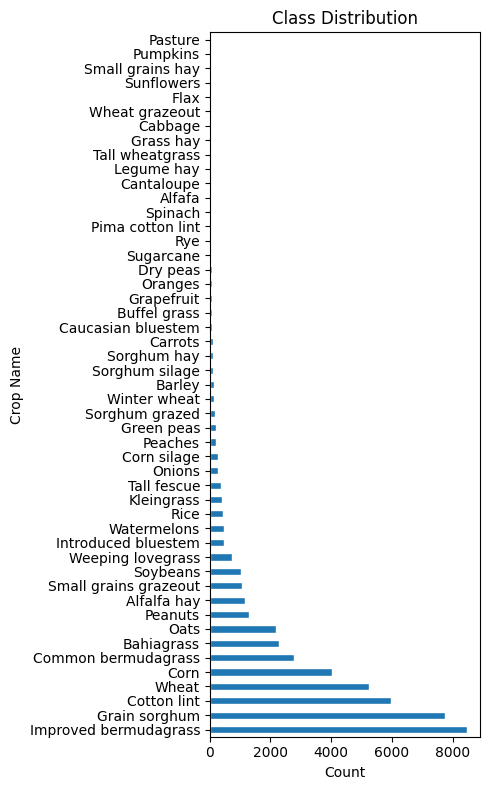

In [23]:
plt.figure(figsize=(5, 8))

# Change 'kind' to 'barh' for horizontal bars
df['cropname'].value_counts().plot(
    kind='barh',
    edgecolor='white', 
    width=0.5
)

# Swap labels to match the new orientation
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Count')       # Now the x-axis shows the count
plt.ylabel('Crop Name')   # Now the y-axis shows the crop names

plt.tight_layout()
plt.show()

#### Map cropname to crop category

In [24]:
# Define the mapping dictionary
crop_mapping = {
    # Cereal Grains
    'Corn': 'Cereal Grains', 'Grain sorghum': 'Cereal Grains', 'Wheat': 'Cereal Grains', 
    'Winter wheat': 'Cereal Grains', 'Oats': 'Cereal Grains', 'Rice': 'Cereal Grains', 
    'Barley': 'Cereal Grains', 'Rye': 'Cereal Grains',
    # Pasture Grasses
    'Improved bermudagrass': 'Pasture Grasses', 'Common bermudagrass': 'Pasture Grasses', 
    'Bahiagrass': 'Pasture Grasses', 'Weeping lovegrass': 'Pasture Grasses', 
    'Introduced bluestem': 'Pasture Grasses', 'Kleingrass': 'Pasture Grasses', 
    'Tall fescue': 'Pasture Grasses', 'Buffel grass': 'Pasture Grasses', 
    'Caucasian bluestem': 'Pasture Grasses', 'Tall wheatgrass': 'Pasture Grasses', 
    'Pasture': 'Pasture Grasses',
    # Hay & Forage
    'Alfalfa hay': 'Hay & Forage', 'Alfafa': 'Hay & Forage', 'Sorghum hay': 'Hay & Forage', 
    'Legume hay': 'Hay & Forage', 'Grass hay': 'Hay & Forage', 'Small grains hay': 'Hay & Forage',
    # Silage & Grazing
    'Corn silage': 'Silage & Grazing', 'Small grains grazeout': 'Silage & Grazing', 
    'Sorghum grazed': 'Silage & Grazing', 'Sorghum silage': 'Silage & Grazing', 
    'Wheat grazeout': 'Silage & Grazing',
    # Fiber Crops
    'Cotton lint': 'Fiber Crops', 'Pima cotton lint': 'Fiber Crops', 'Flax': 'Fiber Crops',
    # Oilseeds & Legumes
    'Peanuts': 'Oilseeds & Legumes', 'Soybeans': 'Oilseeds & Legumes', 
    'Green peas': 'Oilseeds & Legumes', 'Dry peas': 'Oilseeds & Legumes', 
    'Sunflowers': 'Oilseeds & Legumes',
    # Vegetables & Melons
    'Onions': 'Vegetables & Melons', 'Watermelons': 'Vegetables & Melons', 
    'Carrots': 'Vegetables & Melons', 'Spinach': 'Vegetables & Melons', 
    'Cabbage': 'Vegetables & Melons', 'Cantaloupe': 'Vegetables & Melons', 
    'Pumpkins': 'Vegetables & Melons',
    # Fruits
    'Peaches': 'Fruits', 'Grapefruit': 'Fruits', 'Oranges': 'Fruits',
    # Specialty
    'Sugarcane': 'Specialty Crops'
}

# Apply mapping to your dataframe
df['crop_category'] = df['cropname'].map(crop_mapping)
df = df.drop('cropname', axis=1)
print(df['crop_category'].nunique())

9


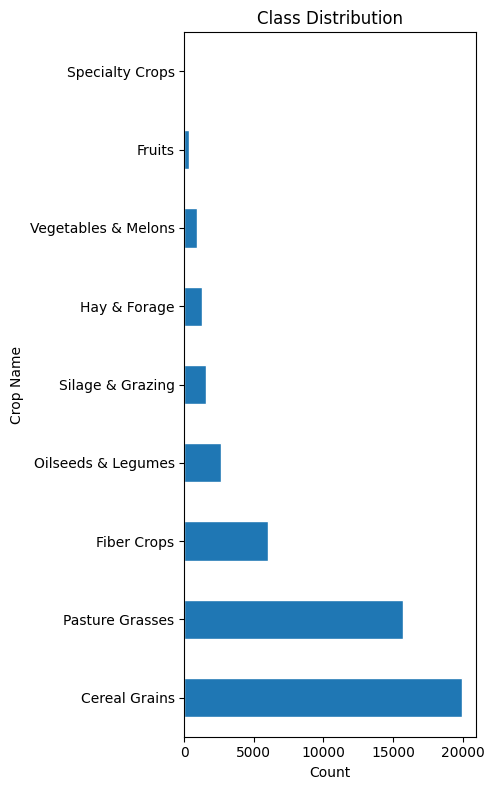

In [ ]:
plt.figure(figsize=(5, 8))

df['crop_category'].value_counts().plot(
    kind='barh',
    edgecolor='white', 
    width=0.5
)

# Plot graph
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Count')
plt.ylabel('Crop Name')

plt.tight_layout()
plt.show()

#### Correlation matrix

In [26]:
# Select numeric colmns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:", num_cols.tolist())

# Select categorical columns
cat_cols = df.select_dtypes(include=['str', 'object']).columns
print("Categorical features:", cat_cols.tolist())

Numeric features: ['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'prcp_1', 'prcp_2', 'prcp_3', 'prcp_4', 'prcp_5', 'prcp_6', 'prcp_7', 'prcp_8', 'prcp_9', 'prcp_10', 'prcp_11', 'prcp_12', 'tmax_1', 'tmax_2', 'tmax_3', 'tmax_4', 'tmax_5', 'tmax_6', 'tmax_7', 'tmax_8', 'tmax_9', 'tmax_10', 'tmax_11', 'tmax_12', 'tmin_1', 'tmin_2', 'tmin_3', 'tmin_4', 'tmin_5', 'tmin_6', 'tmin_7', 'tmin_8', 'tmin_9', 'tmin_10', 'tmin_11', 'tmin_12']
Categorical features: ['taxorder', 'drainagecl', 'crop_category']


In [27]:
# Make a correlation matrix
cm = df[num_cols].corr()
print(cm)

               elev_r   slope_r  hzdepb_r  ph1to1h2o_r      om_r      ec_r  \
elev_r       1.000000 -0.067774 -0.050814     0.465243  0.002675  0.082396   
slope_r     -0.067774  1.000000 -0.095461    -0.098751 -0.181674 -0.100783   
hzdepb_r    -0.050814 -0.095461  1.000000     0.136448 -0.007489  0.031453   
ph1to1h2o_r  0.465243 -0.098751  0.136448     1.000000  0.291713  0.198669   
om_r         0.002675 -0.181674 -0.007489     0.291713  1.000000  0.061256   
ec_r         0.082396 -0.100783  0.031453     0.198669  0.061256  1.000000   
cec7_r      -0.016485 -0.124480  0.043179     0.473132  0.646732  0.160372   
awc_r        0.088509 -0.188558 -0.072967     0.294238  0.382405  0.005177   
prcp_1      -0.591798  0.105853 -0.079516    -0.614701 -0.024124 -0.132870   
prcp_2      -0.611664  0.165076 -0.071827    -0.564125 -0.054472 -0.171130   
prcp_3      -0.609685  0.148778 -0.046698    -0.546402 -0.061732 -0.141272   
prcp_4      -0.591649  0.163729 -0.066494    -0.545987 -0.062132

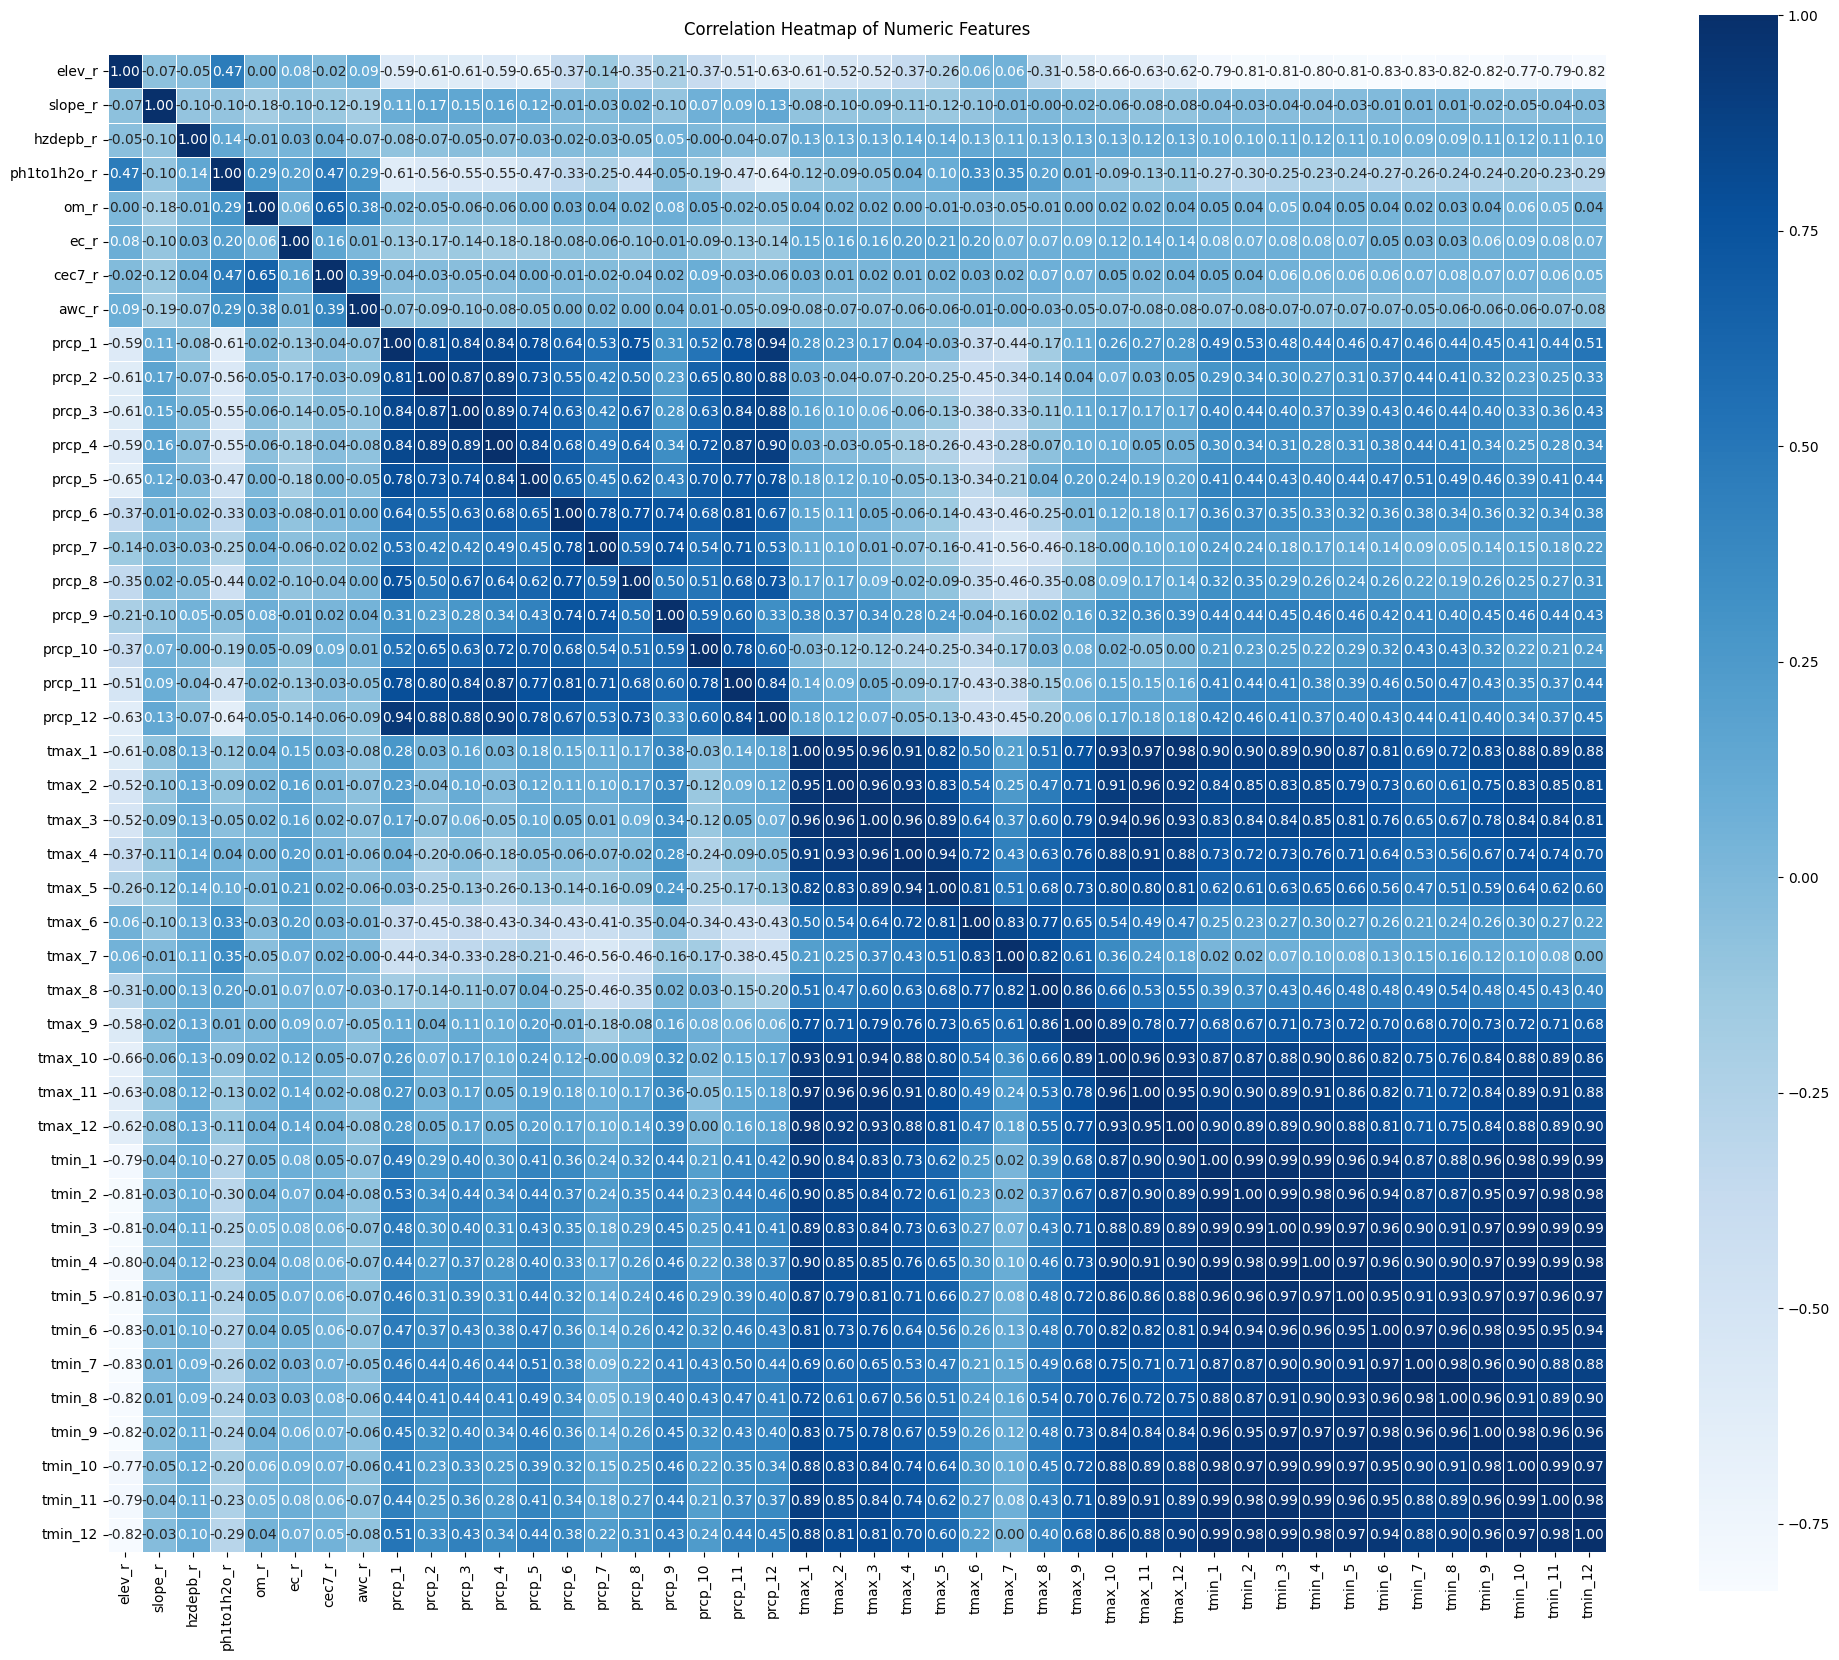

In [49]:
fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

#### Train and test split

In [29]:
X = df.drop('crop_category', axis=1)
y = df['crop_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [30]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['str', 'object']).columns
print(num_cols)
print(cat_cols)

Index(['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r',
       'cec7_r', 'awc_r', 'prcp_1', 'prcp_2', 'prcp_3', 'prcp_4', 'prcp_5',
       'prcp_6', 'prcp_7', 'prcp_8', 'prcp_9', 'prcp_10', 'prcp_11', 'prcp_12',
       'tmax_1', 'tmax_2', 'tmax_3', 'tmax_4', 'tmax_5', 'tmax_6', 'tmax_7',
       'tmax_8', 'tmax_9', 'tmax_10', 'tmax_11', 'tmax_12', 'tmin_1', 'tmin_2',
       'tmin_3', 'tmin_4', 'tmin_5', 'tmin_6', 'tmin_7', 'tmin_8', 'tmin_9',
       'tmin_10', 'tmin_11', 'tmin_12'],
      dtype='str')
Index(['taxorder', 'drainagecl'], dtype='str')


#### Random Forest

In [31]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())

])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(
                    drop='first',
                    handle_unknown='ignore',
                    sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])


In [32]:
rf_pipeline.fit(X_train, y_train)
y_train_pred = rf_pipeline.predict(X_train)
y_test_pred = rf_pipeline.predict(X_test)

print(accuracy_score(y_train, y_train_pred))
print(accuracy_score(y_test, y_test_pred))
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

0.4762223883289945
0.22721649484536083
0.634293799432988
0.0


In [33]:
gmean = make_scorer(geometric_mean_score, average='multiclass')

In [34]:
# param_grid = {
#     'rf__n_estimators': [50, 100, 200],
#     'rf__max_depth': [None, 10, 20]
# }


# grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring=gmean)
# grid_search.fit(X_train, y_train)

# print(f"Best Parameters: {grid_search.best_params_}")

In [35]:
# best_model = grid_search.best_estimator_
# y_test_pred = best_model.predict(X_test)
# print(f"Test G-mean: {geometric_mean_score(y_test, y_test_pred):.4f}")

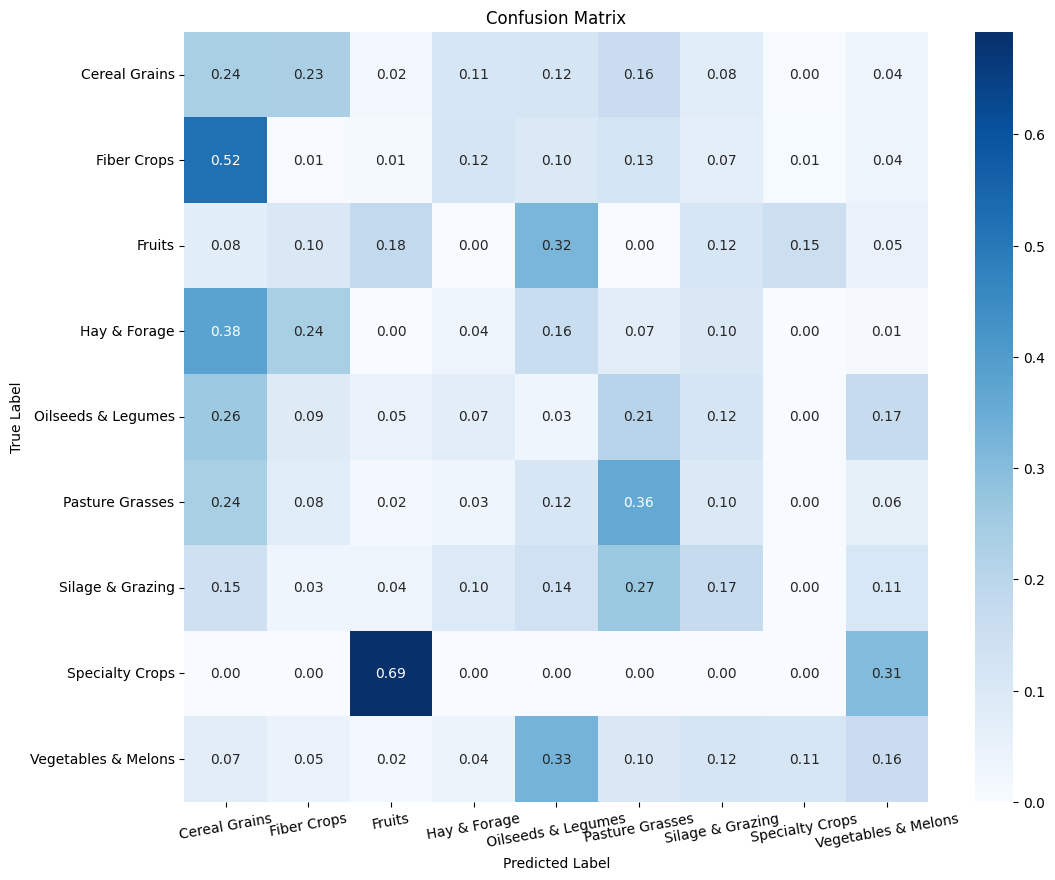

In [36]:
# cnf_matrix = confusion_matrix(y_test, y_test_pred)
# plt.figure(figsize=(12, 10))
# sns.heatmap(cnf_matrix, annot=True, fmt='.2f', cmap='Blues')
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix')
# plt.show()

cnf_matrix = confusion_matrix(y_test, y_test_pred)
cnf_matrix_norm = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cnf_matrix_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=rf_pipeline.classes_,
            yticklabels=rf_pipeline.classes_)
plt.xticks(rotation=10)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### Imbalanced random forest

In [50]:
imb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('oversample',  SMOTE(random_state=42)),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('rf', RandomForestClassifier(class_weight='balanced'))
])

In [51]:
imb_pipeline.fit(X_train, y_train)
y_train_pred = imb_pipeline.predict(X_train)
y_test_pred = imb_pipeline.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

Train Accuracy: 0.5785
Test Accuracy: 0.3527
0.26646695554535493
0.0


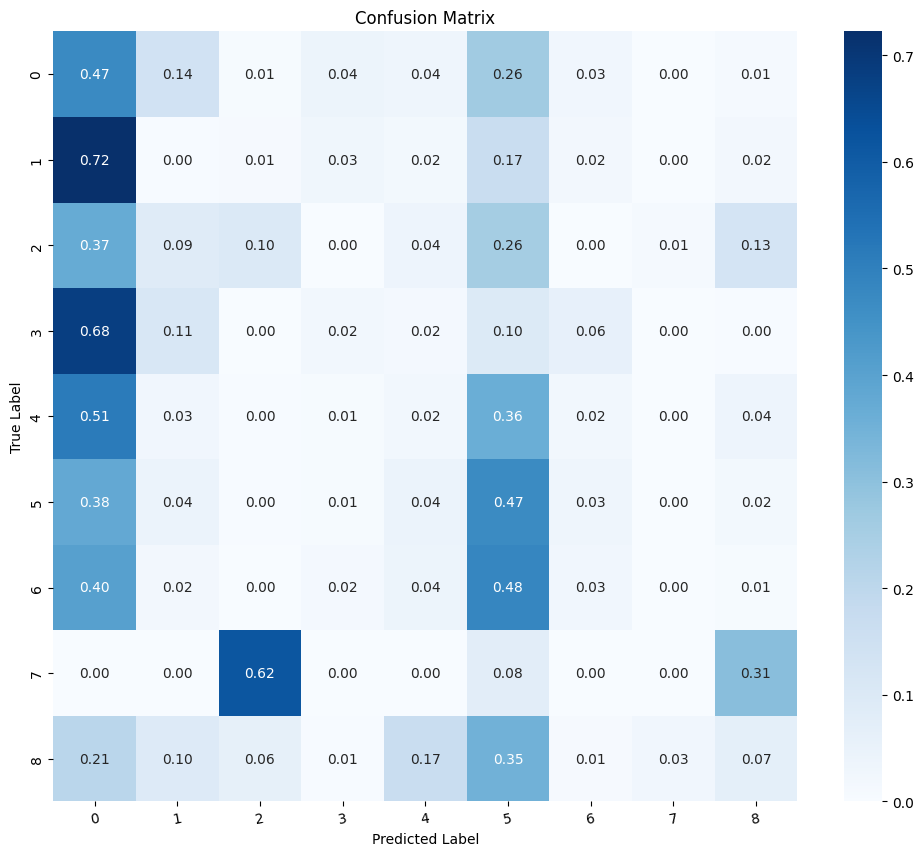

In [52]:
cnf_matrix = confusion_matrix(y_test, y_test_pred)
cnf_matrix_norm = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cnf_matrix_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=imb_pipeline.classes_,
            yticklabels=imb_pipeline.classes_)
plt.xticks(rotation=10)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### XGBoost

In [37]:
from xgboost import XGBClassifier
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier())
])

In [38]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [39]:
xgb_pipeline.fit(X_train, y_train)
y_train_pred = xgb_pipeline.predict(X_train)
y_test_pred = xgb_pipeline.predict(X_test)

print(accuracy_score(y_train, y_train_pred))
print(accuracy_score(y_test, y_test_pred))
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

0.563986906204088
0.5061855670103093
0.14693302378846593
0.0


#### KNN

In [40]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

In [41]:
knn_pipeline.fit(X_train, y_train)
y_train_pred = knn_pipeline.predict(X_train)
y_test_pred = knn_pipeline.predict(X_test)

print(accuracy_score(y_train, y_train_pred))
print(accuracy_score(y_test, y_test_pred))
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))


0.5563058999407171
0.43731958762886597
0.0
0.0


In [42]:
X_train_prepped = preprocessor.fit_transform(X_train)
X_test_prepped = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
knn = KNeighborsClassifier(n_neighbors=5)

sfs = SequentialFeatureSelector(knn, n_features_to_select=5, direction='forward', cv=5)
sfs.fit(X_train_prepped, y_train)

selected_indices = sfs.get_support()
selected_features = feature_names[selected_indices]

knn.fit(X_train_prepped[:, selected_indices], y_train)
result = permutation_importance(
    knn, X_test_prepped[:, selected_indices], y_test, n_repeats=10, random_state=42
)

sorted_idx = result.importances_mean.argsort()

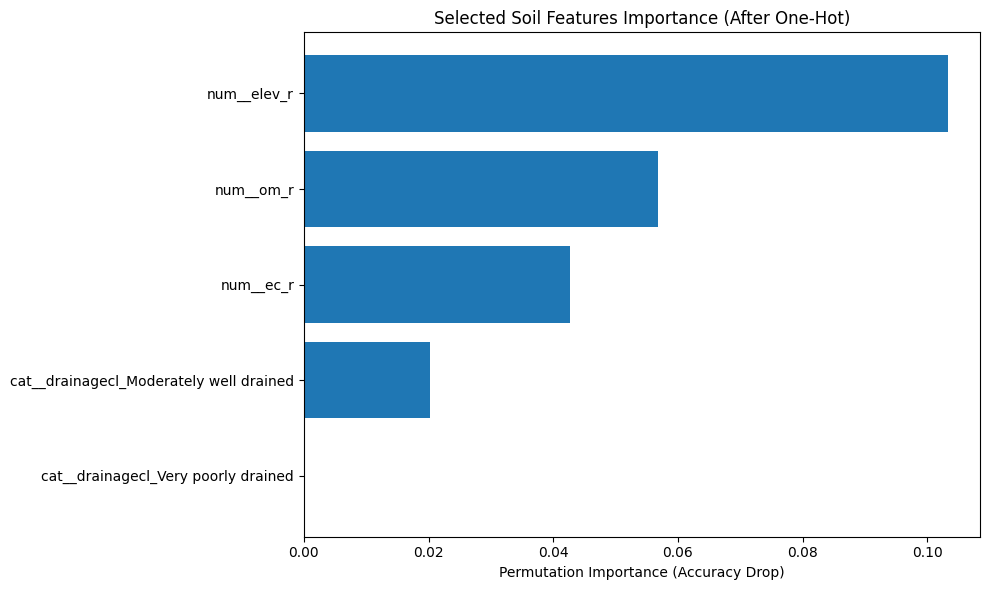

Selected features: ['num__elev_r' 'num__om_r' 'num__ec_r'
 'cat__drainagecl_Moderately well drained'
 'cat__drainagecl_Very poorly drained']


In [43]:
plt.figure(figsize=(10, 6))
plt.barh(selected_features[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Accuracy Drop)")
plt.title("Selected Soil Features Importance (After One-Hot)")
plt.tight_layout()
plt.show()

print("Selected features:", selected_features)

In [44]:
selected_features = ['elev_r', 'cec7_r', 'awc_r']
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

simple_knn_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5)) 
])

simple_knn_pipeline.fit(X_train_selected, y_train)
y_train_pred = simple_knn_pipeline.predict(X_train_selected)
y_test_pred = simple_knn_pipeline.predict(X_test_selected)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(geometric_mean_score(y_train, y_train_pred))
print(geometric_mean_score(y_test, y_test_pred))

Train Accuracy: 0.5106
Test Accuracy: 0.4725
0.0
0.0
